# Рабочая тетрадь по ПСИИ №2

## БФБО-06-24 Петров Артем

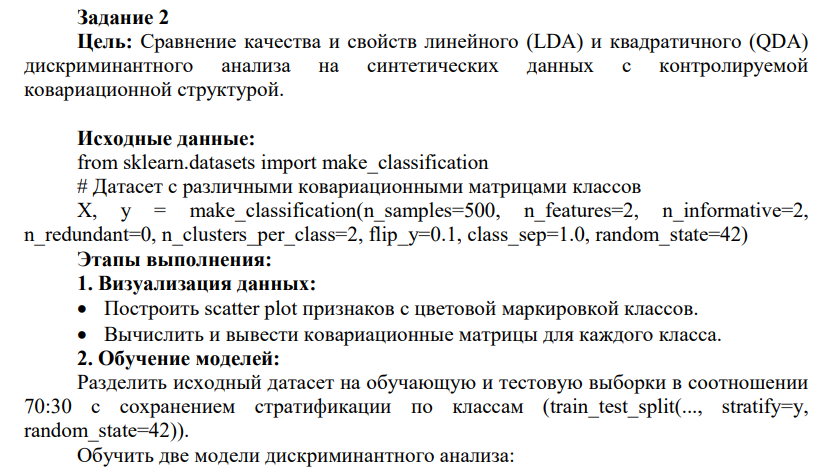

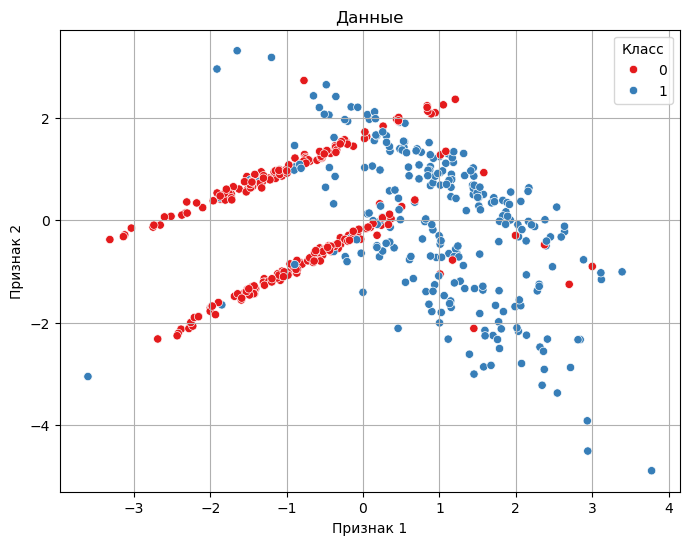

Ковариационная матрица для класса 0:
[[1.01196264 0.34909971]
 [0.34909971 1.26875246]];

Ковариационная матрица для класса 1:
[[ 1.16449405 -0.75118396]
 [-0.75118396  2.07966236]];



In [31]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
# Датасет с различными ковариационными матрицами классов
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, 
                           n_redundant=0, n_clusters_per_class=2, flip_y=0.1, class_sep=1.0, random_state=42)

# Визуализация изначальных данных при помощи seaborn и matplotlib
plt.figure(figsize = (8, 6))
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y, palette = 'Set1')
plt.title('Данные')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend(title = 'Класс')
plt.grid()
plt.show()

# Разделение данных по классам и вычисление ковариационных матриц:
cov_matrix_c_0 = np.cov(X[y == 0].T) # Транспонирование происходит т.к. признаки ожидаютс в строках
cov_matrix_c_1 = np.cov(X[y == 1].T)

# Вывод результатов:
print(f"Ковариационная матрица для класса 0:\n{cov_matrix_c_0};\n")
print(f"Ковариационная матрица для класса 1:\n{cov_matrix_c_1};\n")

# Разделение на тренировочные и тестовые выборки:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)

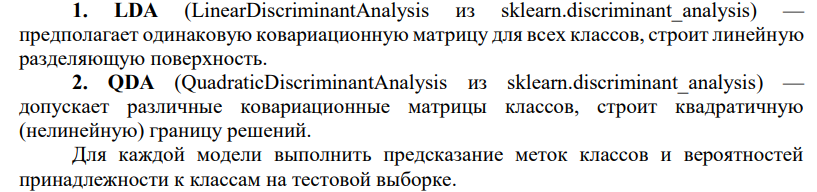

In [23]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
LDA = LinearDiscriminantAnalysis()
LDA.fit(X_train, y_train)
LDA_pred = LDA.predict(X_test)
LDA_proba = LDA.predict_proba(X_test)

QDA = QuadraticDiscriminantAnalysis()
QDA.fit(X_train, y_train)
QDA_pred = QDA.predict(X_test)
QDA_proba = QDA.predict_proba(X_test)

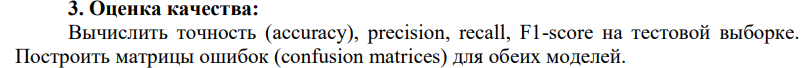

Значения метрик для LDA:

accuracy: 0.84;
precision: 0.8170731707317073;
recall: 0.881578947368421;
f1_score: 0.8481012658227848.

Значения метрик для QDA:

accuracy: 0.86;
precision: 0.8235294117647058;
recall: 0.9210526315789473;
f1_score: 0.8695652173913043.


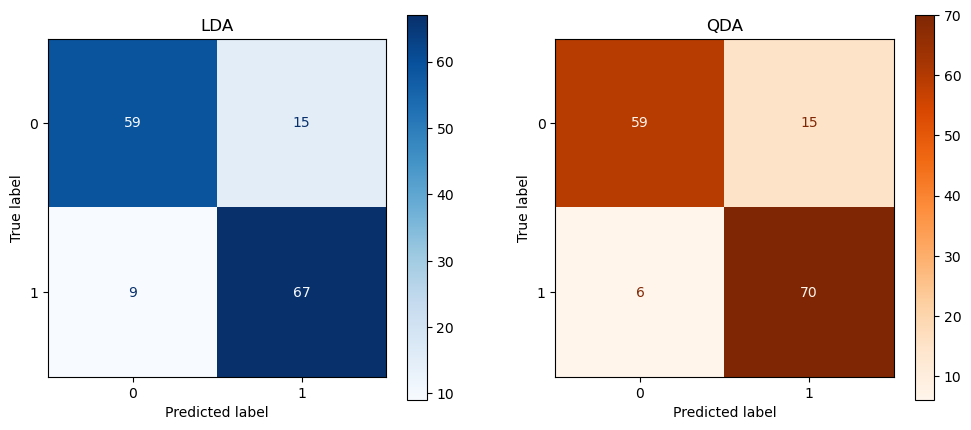

In [25]:
# Вывод значений метрик:
print(f"Значения метрик для LDA:\n\naccuracy: {accuracy_score(y_test, LDA_pred)};\nprecision: {precision_score(y_test, LDA_pred)};\nrecall: {recall_score(y_test, LDA_pred)};\nf1_score: {f1_score(y_test, LDA_pred)}.\n")
print(f"Значения метрик для QDA:\n\naccuracy: {accuracy_score(y_test, QDA_pred)};\nprecision: {precision_score(y_test, QDA_pred)};\nrecall: {recall_score(y_test, QDA_pred)};\nf1_score: {f1_score(y_test, QDA_pred)}.")

# Визуализация (для наглядности) матрицы ошибок:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, LDA_pred, ax = axes[0], cmap = 'Blues')
axes[0].set_title('LDA')
ConfusionMatrixDisplay.from_predictions(y_test, QDA_pred, ax=axes[1], cmap = 'Oranges')
axes[1].set_title('QDA')
plt.show()

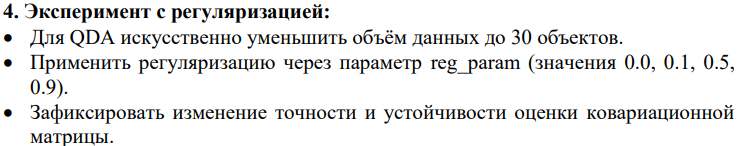

QDA with reg_param = 0.0: Accuracy = 0.86;
QDA with reg_param = 0.1: Accuracy = 0.86;
QDA with reg_param = 0.5: Accuracy = 0.8466666666666667;
QDA with reg_param = 0.9: Accuracy = 0.8333333333333334;


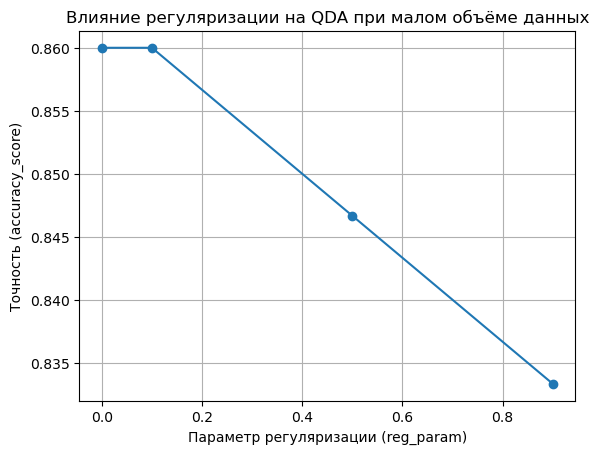

In [34]:
# Объявление уменьшенных данных:
X1_train, _, y1_train, _ = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 42)

# Теперь зафиксируем изменение точности с разными значениями параметра регуляризации:
reg_params = [0.0, 0.1, 0.5, 0.9] # при 0.0 - обычный QDA, при 1.0 - обычный LDA
accuracies = []

for i in reg_params:
    QDA_reg = QuadraticDiscriminantAnalysis(reg_param = i)
    QDA_reg.fit(X1_train, y1_train)
    accuracies.append(accuracy_score(y_test, QDA_reg.predict(X_test)))
    print(f'QDA with reg_param = {i}: Accuracy = {accuracy_score(y_test, QDA_reg.predict(X_test))};')

# Визуализация изменений:
plt.plot(reg_params, accuracies, marker = 'o')
plt.xlabel('Параметр регуляризации (reg_param)')
plt.ylabel('Точность (accuracy_score)')
plt.title('Влияние регуляризации на QDA при малом объёме данных')
plt.grid()
plt.show()

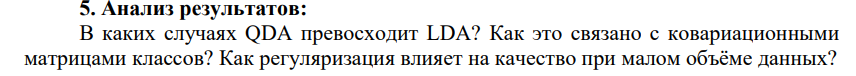

## В каких случаях QDA превосходит LDA?

QDA выигрывает, когда данные в классах имеют разную форму (разброс). К примеру, если точки первого класса образуют "облако" или вытянутый эллипс, а второго - круг. В случае с нашими данными - QDA выигрывает, хоть и не сильно.

## Как это связано с ковариационными матрицами классов?

При значительных отличия ковариационых матриц одного класса от другого будет выигрывать QDA, так как данный метод образует кривую, которая огибает неровности. Если же матрицы будут практически одинаковыми или не будут иметь сильных отличий, то LDA покажет идентичный или даже лучший результат. В нашем случае, матрицы одного класса незначительно отличаются от второго, но этого достаточно, чтобы QDA немного превосходил LDA.

## Как регуляризация влияет на качество при малом объёме данных?

При небольшом увеличении параметра регуляризации точность должна вырасти (стабилизация оценки ковариации), а потом при большем увеличении будет падать, потому что модель становится ближе к LDA и теряет свою гибкость. В нашем случае, на отметке параметра регуляризации 0.1 точность остаётся идентичной обычному QDA (регуляризация 0.0), но по мере увеличения точность начинает падать и приближаться к точности LDA.